In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [33]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [34]:
import os

print("Files in dataset folder:")
print(os.listdir(path))

Files in dataset folder:
['creditcard.csv']


In [35]:
['creditcard.csv']

['creditcard.csv']

In [36]:
file_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.1412

In [37]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [38]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [39]:
print(df["Class"].value_counts())

print("\nFraud Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    283253
1       473
Name: count, dtype: int64

Fraud Percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


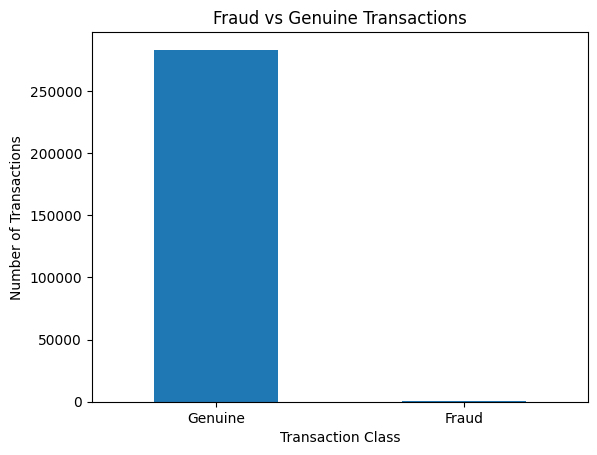

In [40]:
df["Class"].value_counts().plot(kind="bar")

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Genuine", "Fraud"], rotation=0)
plt.show()

In [41]:
print("Average transaction amount:")
print(df.groupby("Class")["Amount"].mean())

print("\nMaximum transaction amount:")
print(df.groupby("Class")["Amount"].max())

print("\nMinimum transaction amount:")
print(df.groupby("Class")["Amount"].min())

Average transaction amount:
Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64

Maximum transaction amount:
Class
0    25691.16
1     2125.87
Name: Amount, dtype: float64

Minimum transaction amount:
Class
0    0.0
1    0.0
Name: Amount, dtype: float64


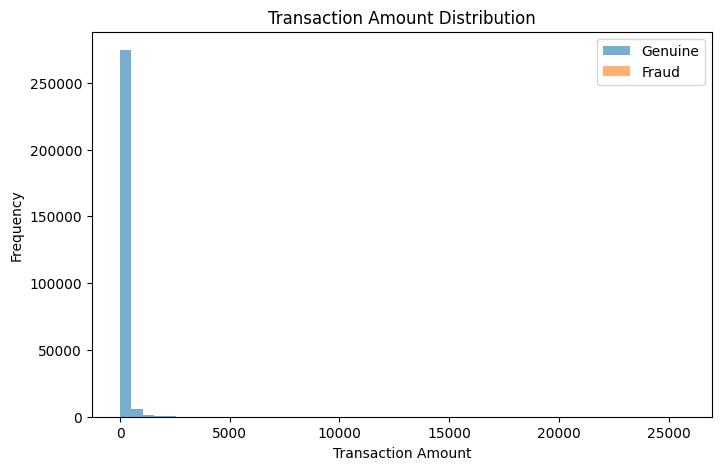

In [42]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Class"] == 0]["Amount"],
    bins=50,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    df[df["Class"] == 1]["Amount"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.legend()
plt.show()

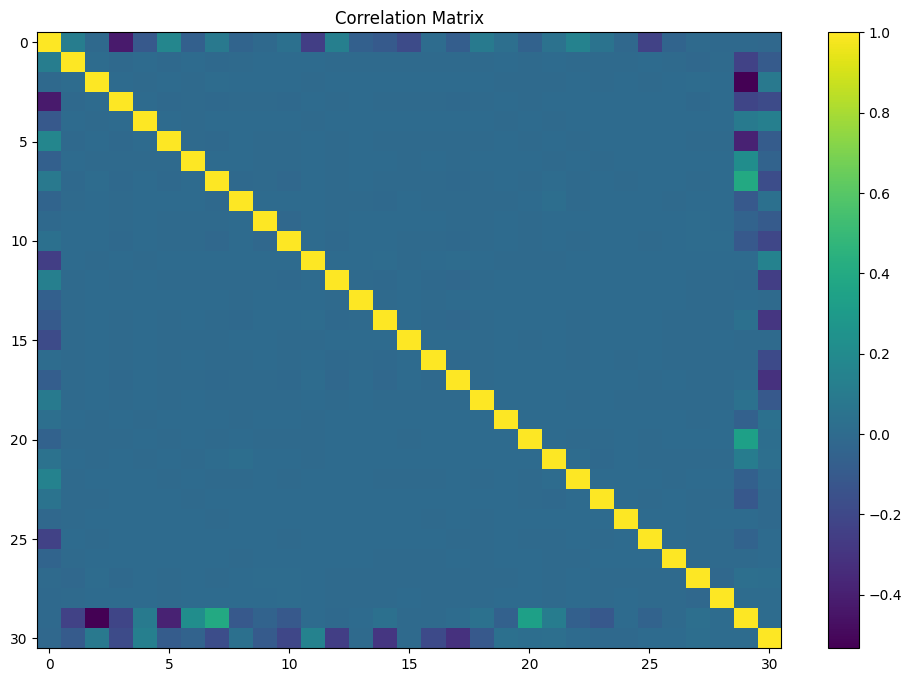

In [43]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.title("Correlation Matrix")
plt.show()

In [44]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (283726, 30)
Target: (283726,)


In [45]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (226980, 30)
Testing data: (56746, 30)


In [30]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [47]:
y_pred = model.predict(X_test)

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9994713283755683
Precision: 0.9710144927536232
Recall   : 0.7052631578947368
F1 Score : 0.8170731707317073


In [49]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



Confusion Matrix:
[[56649     2]
 [   28    67]]


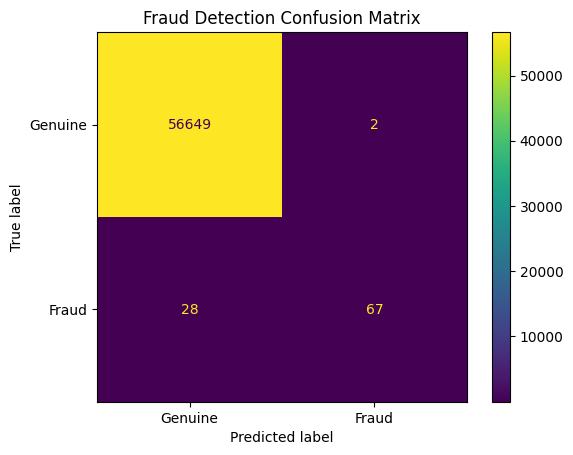

In [50]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

disp.plot()
plt.title("Fraud Detection Confusion Matrix")
plt.show()

In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

   Feature  Importance
14     V14    0.185850
10     V10    0.119370
12     V12    0.100298
17     V17    0.094327
4       V4    0.093938
3       V3    0.059883
16     V16    0.056158
11     V11    0.053692
2       V2    0.035532
9       V9    0.025911
7       V7    0.016854
19     V19    0.015383
21     V21    0.014855
18     V18    0.012170
8       V8    0.011347


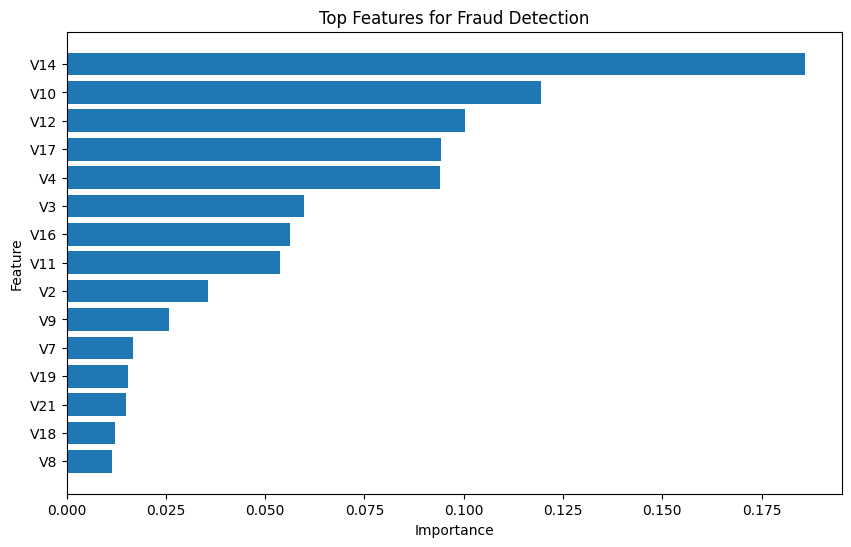

In [52]:
top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features for Fraud Detection")
plt.gca().invert_yaxis()

plt.show()

In [53]:
predicted_fraud = df.iloc[
    np.where(model.predict(X_scaled) == 1)[0]
]

print("Number of suspicious transactions:",
      len(predicted_fraud))

print(predicted_fraud.head())

Number of suspicious transactions: 446
        Time        V1        V2        V3        V4        V5        V6  \
541    406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
623    472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
6108  6986.0 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536   
6329  7519.0  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746   
6331  7526.0  0.008430  4.137837 -6.240697  6.675732  0.768307 -3.353060   

            V7        V8        V9  ...       V21       V22       V23  \
541  -2.537387  1.391657 -2.770089  ...  0.517232 -0.035049 -0.465211   
623   0.325574 -0.067794 -0.270953  ...  0.661696  0.435477  1.375966   
6108 -3.496197 -0.248778 -0.247768  ...  0.573574  0.176968 -0.436207   
6329  1.713445 -0.496358 -1.282858  ... -0.379068 -0.704181 -0.656805   
6331 -1.631735  0.154612 -2.795892  ...  0.364514 -0.608057 -0.539528   

           V24       V25       V26       V27       V28  Amount  C

In [54]:
print("========== FRAUD DETECTION SUMMARY ==========")

print("Total Transactions :", len(df))
print("Genuine Transactions:", (df["Class"] == 0).sum())
print("Fraud Transactions  :", (df["Class"] == 1).sum())

print("\nModel Performance")
print("----------------------------")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

========== FRAUD DETECTION SUMMARY ==========
Total Transactions : 283726
Genuine Transactions: 283253
Fraud Transactions  : 473

Model Performance
----------------------------
Accuracy : 99.95 %
Precision: 97.1 %
Recall   : 70.53 %
F1 Score : 81.71 %
